## 3. Discretização, derivadas e integrais numéricas

Muitas aplicações de métodos numéricos requerem a discretização do domínio, como por exemplo a derivação e a integração numérica de funções de uma variável. 

A derivada de uma função $f(x)$ no ponto $x=p$ é definida como:

$$f'(p) = \lim\limits_{x \to p}\frac{f(x) - f(p)}{x-p}$$

Geometricamente a derivada de $f(x)$ em $x=p$ é a inclinação da reta tangente à função neste ponto, ou simplesmente, a inclinação da função. Assim, a derivada informa sobre a taxa de variação instantânea da função no ponto $x=p$.

Além disso, tomando $p$ suficientemente próximo de $x$ podemos inferir que uma boa aproximação para o valor da derivada 1ª de $f$ em $x$ será dada por 

$$f'(p) \approx \frac{f(x) - f(p)}{x-p}$$

Essa fórmula, conhecida como _diferença finita à direita_ fornece um valor aproximado para a inclinação da reta tangente usando a inclinação da reta secante à $f$ que intercepta o gráfico nos pontos $(x,f(x))$ e $(p, f(p))$.  

<img src="https://github.com/tiagoburiol/MatComp_III/blob/main/Notebook%2003%20-%20Discretiza%C3%A7%C3%A3o%2C%20derivadas%20e%20integrais%20num%C3%A9ricas/imagens/derivada.png?raw=true" width="480">
<p style="text-align: center;">Figura 3.1 - Interpretação geométrica da derivada </p>

Podemos concluir facilmente que quanto mais próximo o ponto $p$ estiver de $x$, mais próxima a inclinação da reta secante estará da reta tangente. Em outras palavras, quanto menor o valor de $h=x-p$ melhor a aproximação obtida. 

**Discretização:** Obter numericamente aproximações para a derivada de uma função, portanto, requer discretizar uma região do domínio. No caso da uma função $y=f(x)$, podemos tomar $n+1$ pontos $x_i$, $i=0,1,...,n$ no intervalo $[x_0,x_n]$ como mostra a figura abaixo.

<img src="https://github.com/tiagoburiol/MatComp_III/blob/main/Notebook%2003%20-%20Discretiza%C3%A7%C3%A3o%2C%20derivadas%20e%20integrais%20num%C3%A9ricas/imagens/grid.png?raw=true" width="500">
<p style="text-align: center;">Figura 3.2 - Discretização de um intervalo do domínio da função</p>

Podemos então, obter valores aproximados para a derivada de qualquer função em um conjunto discreto de pontos $x_1, x_2,...,x_n$ usando a fórmuda de diferença finita à direita com os pontos $x_i$ e $x_{i+1}$ com $i=0,1,...,n-1$. Vejamos alguns exemplos a seguir.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (4, 3)
trapz = getattr(np, "trapezoid", np.trapz)  # compatibilidade: NumPy >= 2.0 renomeou np.trapz para np.trapezoid

**Exemplo 3.1:** *(Discretização e cálculo da derivada numérica)* Neste exemplo vamos obter aproximações numéricas para a derivada da função $\text{sen}\,x$ em um intervalo, discretizado em um conjunto de 21 pontos distribuídos de duas formas diferentes e, então, fazer o gráfico e calcular o erro quadrático médio para cada caso. 

Sabemos que a derivada primeira de $f(x)=sen(x)$ é $f'(x)=cos(x)$. Vamos calcular as derivadas numericamente e comparar os gráficos para alguns valores de $x$ dividindo o intervalo $(0, 2\pi)$ em 21 pontos igualmente espaçados. 

In [2]:
# discretizando o intervalo (0,2pi)
xi = np.linspace(0, 2*np.pi, 21)
print (xi)

[0.         0.31415927 0.62831853 0.9424778  1.25663706 1.57079633
 1.88495559 2.19911486 2.51327412 2.82743339 3.14159265 3.45575192
 3.76991118 4.08407045 4.39822972 4.71238898 5.02654825 5.34070751
 5.65486678 5.96902604 6.28318531]


In [3]:
# obtendo as diferenças em xi
dxi = np.diff(xi)
print(dxi)

[0.31415927 0.31415927 0.31415927 0.31415927 0.31415927 0.31415927
 0.31415927 0.31415927 0.31415927 0.31415927 0.31415927 0.31415927
 0.31415927 0.31415927 0.31415927 0.31415927 0.31415927 0.31415927
 0.31415927 0.31415927]


Observe que a distância entre dois pontos consecutivos é constante e igual a $\frac{2\pi}{20}$ pois discretizamos o intervalo em 20 subintervalos de mesmo tamanho. O mesmo resultado acima poderia ser obtido fazendo `xi[1:]-xi[0:-1]`, ou ainda, `np.full(20, 2*np.pi/20)`, verifique!

In [4]:
# obtendo as diferenças em f(xi)=yi
yi = np.sin(xi)
dyi = np.diff(yi)
print(dyi)

[ 0.30901699  0.27876826  0.22123174  0.14203952  0.04894348 -0.04894348
 -0.14203952 -0.22123174 -0.27876826 -0.30901699 -0.30901699 -0.27876826
 -0.22123174 -0.14203952 -0.04894348  0.04894348  0.14203952  0.22123174
  0.27876826  0.30901699]


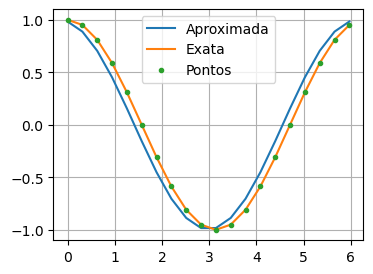

In [5]:
# plotando as derivadas aproximadas e exata
plt.plot(xi[0:-1], dyi/dxi, label='Aproximada')
plt.plot(xi[0:-1], np.cos(xi[0:-1]), label='Exata')
plt.plot(xi[0:-1], np.cos(xi[0:-1]), '.', label='Pontos')
plt.grid()
plt.legend()
plt.show()

Para ter uma ideia da precisão do resultado obtido podemos calcular o erro quadrático médio
$$Err=\frac{1}{N} \sum_{i=0}^{N-1}\left(\frac{d y_i}{d x_i}-\cos \left(x_i\right)\right)^2$$
fazendo

In [6]:
err =np.sum((dyi/dxi-np.cos(xi[0:-1]))**2)/len(xi[0:-1])
print("EQM = ",err)

EQM =  0.01226952697198515


A função `np.gradient` utiliza diferenças centrais de segunda ordem

$$f^{\prime}\left(x_i\right) \approx \frac{f\left(x_{i+1}\right)-f\left(x_{i-1}\right)}{2 h}$$

nos pontos interiores do intervalo, fornecendo uma aproximação melhor, e diferenças unilaterais de primeira ou segunda ordem (para frente ou para trás) nos limites do intervalo. O vetor gradiente devolvido, portanto, tem o mesmo tamanho do vetor de entrada. O mesmo exemplo anterior, usando a função `np.gradient`.

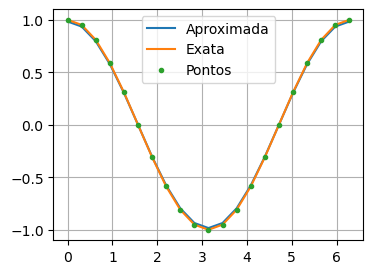

In [7]:
dfi = np.gradient(yi,xi)

# plotando as derivadas aproximadas e exata
plt.plot(xi, dfi, label='Aproximada')
plt.plot(xi, np.cos(xi), label='Exata')
plt.plot(xi, np.cos(xi), '.', label='Pontos')
plt.grid()
plt.legend()
plt.show()

In [8]:
err =np.sum((dfi-np.cos(xi))**2)/len(xi)
print("EQM:",err)

EQM: 0.00014034067569607228


Observe que o erro quadrático médio é menor.

Agora observemos que nos intervalos em que a inclinação da curva apresenta maior variação, a tendência é da derivada numérica apresentar um erro maior. Vamos modificar a discretização do intervalo de $0$ a $2\pi$ diminuindo o espaçamento entre os pontos próximos de $x=0$, $x=\pi$ e de $x=2\pi$.

In [9]:
x1 = np.linspace(0, 1.0, 6)
x2 = np.linspace(1.0, 2.5, 3)
x3 = np.linspace(2.5, 3.75, 6)
x4 = np.linspace(3.75, 5.25, 3)
x5 = np.linspace(5.25, 2*np.pi, 7)
xi = np.concatenate((x1[:-1], x2[:-1],x3[:-1], x4[:-1], x5))
print(len(xi))
print(xi)

21
[0.         0.2        0.4        0.6        0.8        1.
 1.75       2.5        2.75       3.         3.25       3.5
 3.75       4.5        5.25       5.42219755 5.5943951  5.76659265
 5.9387902  6.11098776 6.28318531]


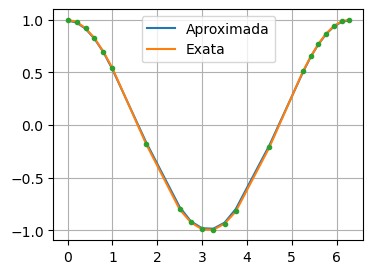

In [10]:
yi = np.sin(xi)
dfi = np.gradient(yi,xi)


# plotando as derivadas aproximadas e exata
plt.plot(xi, dfi, label='Aproximada')
plt.plot(xi, np.cos(xi), label='Exata')
plt.plot(xi, np.cos(xi), '.')

plt.grid()
plt.legend()
plt.show()

In [11]:
err = np.sum((dfi-np.cos(xi))**2)/len(xi)
print("Erro quadrático médio:",err)

Erro quadratico médio: 0.00011964200679385693


**Atividade 3.1:** Use esse exemplo para estudar a derivada numérica de outras funções com diferentes formas de discretização do intervalo. Compare e observe que quanto maior o número de pontos menor o erro de aproximação. 

Algumas funções sugeridas:

a) $f(x)=e^{2x}$

b) $f(x)=x ln(x)$

c) $f(x)=x cos(x)-x^2sen(x)$

d) $f(x)=2ln(x)^2+3sen(x)$

e) $f(x)=2^xsen(x)$

f) $f(x)=x^2e^x$

Para obter a solução exata para comparação, experimente a biblioteca `sympy` como é mostrado abaixo. Aqui usaremos a função da letra e) como exemplo. 

In [12]:
import sympy as sp

x, y = sp.symbols('x y')
f = 2**x*sp.sin(x)
df = sp.diff(f, x)
df

2**x*log(2)*sin(x) + 2**x*cos(x)

Experimente converter a derivada obtida com Sympy em uma função do numpy usando `lambdify`. Um exemplo é mostrado a seguir:

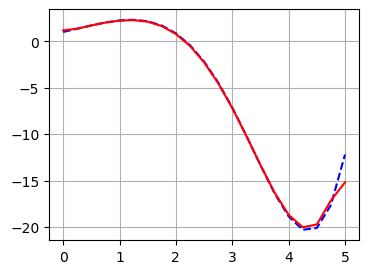

In [13]:
# transformando uma função do sympy em função lambda 
df = sp.lambdify(x, sp.diff(f, x))

# obtendo os ponto para plotar
xi = np.linspace(0,5,21)  
yi = 2**xi*np.sin(xi)

# plotando a derivada exata e aproximada
plt.plot(xi, df(xi),'b--',label='Exata')
plt.plot(xi, np.gradient(yi,xi), 'r',label='Aproximada')
plt.grid()
plt.show()

**Exemplo 3.2:** Discretização e cálculo da integral numérica

A forma mais simples de obter um valor aproximado para uma integral definida é por meio da soma de Riemann em que divide-se o intervalo de integração $(a,b)$ em $n$ subintervalos e somam-se as áreas dos retângulos definidos em cada subintervalo. 


A largura de cada retângulo será dado por $h=\frac{x_n-x_0}{n}$ e a altura será dada por $f(x)$ para algum $x$ dentro do subintervalo $[x_i,x_{i+1}]$, com $i=0,1,...,n$. Uma escolha natural para o valor de $x$ é um dos extremos do intervalo, o extremo esquerdo $x_i$ ("pela esquerda") ou o extremo direito $x_{i+1}$ ("pela direita"):

<img src="https://github.com/tiagoburiol/MatComp_III/blob/main/Notebook%2003%20-%20Discretiza%C3%A7%C3%A3o%2C%20derivadas%20e%20integrais%20num%C3%A9ricas/imagens/Riemann.png?raw=true" width="600">

<p style="text-align: center;">Figura 3.3 - Discretização de um intervalo do domínio da função</p>
Claramente podemos aumentar a acurácia da aproximação obtida aumentando o número de subintervalos. A _regra do ponto médio_ considera a altura do retângulo definida em cada subintervalo como sendo o valor da função no ponto médio entre $x_i$ e $x_{i+1}$:

$$\int_a^b f(x)dx \approx \sum_{i = 0}^{n-1} hf\left(\frac{x_i+x_{i+1}}{2} \right)$$


**Discretização:** Obter numericamente aproximações para uma integral definida requer, portanto, discretizar o intervalo de integração. Isso pode ser feito dividindo o intervalo $(a,b)$ em $n$ subintervalos de amplitude $h = \frac{b-a}{n}$ e obtendo as coordenadas dos pontos fazendo $x_i = x_0+hi$, com $i=1,2,...n-1$.

**Cálculo da integral numérica:** Vamos calcular a integral $\int_{0.1}^{0.8} x^2ln(x)dx$ usando `sympy` para obter a solução exata e, então, vamos obter aproximações usando soma de Riemann pela esquerda, pela direita e pela regra do ponto médio, e comparar os resultados. 

Primeiramente vamos obter a primitiva usando `sympy`.

In [14]:
import sympy as sp

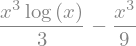

In [15]:
x = sp.symbols('x')
sp.init_printing(use_unicode=True)

f = x**2*sp.log(x)
F = sp.integrate(f, x)
F

Calculando o resultado a integral definida

In [16]:
F = sp.lambdify (x, F)
I = F(0.8)-F(0.1)
print(I)

-0.0940934155044049


Agora o resultado aproximado pela soma de Riemann com oito subintervalos (nove pontos).

In [17]:
xi = np.linspace(0.1, 0.8, 9)
h = xi[1]-xi[0]
print ("h=",h)

h= 0.0875


In [18]:
f = lambda x: x**2*np.log(x)

In [19]:
Ie = h*np.sum(f(xi[0:-1]))
print("Ie=",Ie, "Erro=",abs(I-Ie))

Ie= -0.08833876053340978 Erro= 0.0057546549709951295


In [20]:
Id = h*np.sum(f(xi[1:]))
print("Id=",Id, "Erro=",abs(I-Id))

Id= -0.09882003745063572 Erro= 0.004726621946230816


In [21]:
Im = h*np.sum(f((xi[0:-1]+xi[1:])/2))
print("Im=",Im, "Erro=",abs(I-Im))

Im= -0.0943509348508234 Erro= 0.00025751934641848884


Nesse exemplo é possível notar que a regra do ponto médio forneceu a melhor aproximação.

A biblioteca `numpy` implementa a conhecida regra dos trapézios para integração numérica na função `trapz`. Para isso é preciso entrar com os valores da função no intervalo já discretizado, ou informar o tamanho do passo $h=dx$. Um exemplo é mostrado abaixo.

In [22]:
It = trapz(f(xi),xi)
print("It=",It, "Erro=",abs(I-It))

It= -0.09357939899202276 Erro= 0.0005140165123821427


ou

In [23]:
It = trapz(f(xi),dx=h)
print("It=",It, "Erro=",abs(I-It))

It= -0.09357939899202275 Erro= 0.0005140165123821566


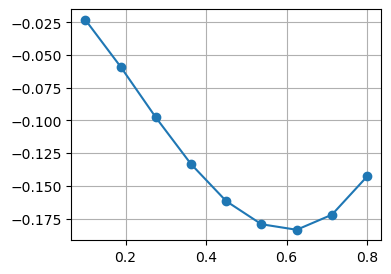

In [24]:
plt.plot(xi,f(xi),"o-")
plt.grid()
plt.show()

Observe que nos 4 primeiros pontos do gráfico acima a função se comporta como uma reta, assim, podemos mudar a posição dos pontos de modo a melhorar o resultado da aproximação apenas discretizando o intervalo de forma diferente. Aumentando o espaçamento dos pontos onde a função tem menor curvatura e diminuindo onde a função tem maior curvatura obtemos um resultado melhor com o mesmo número de pontos. Vejamos o exemplo a seguir. 

In [25]:
xi = np.array([0.1,0.3,0.425,0.5,0.55,0.615,0.685,0.75,0.8])
f = lambda x: x**2*np.log(x)
It = trapz(f(xi),xi)
print("It=",It, "Erro=",abs(I-It))

It= -0.0938642211312475 Erro= 0.00022919437315740976


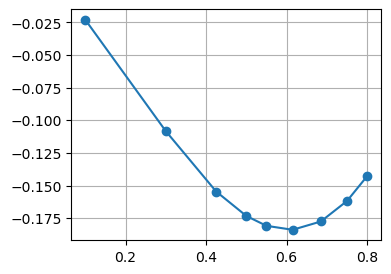

In [26]:
plt.plot(xi,f(xi),"o-")
plt.grid()
plt.show()

A biblioteca `scipy` implementa outros métodos de integração numérica, a partir de um conjunto discreto de pontos da função. A seguir mostramos como usar o método de Simpson e o método de Romberg (número de intervalos precisa ser uma potência de 2). Vejamos os exemplos a seguir usando a mesma função do exemplo anterior e diferentes discretizações.

In [27]:
from scipy import integrate
xi = np.linspace(0.1,0.8,9)
Is = integrate.simpson(f(xi), x=xi)
print("Is=",Is, "Erro=",abs(I-Is))

Is= -0.09409838517861327 Erro= 4.969674208363251e-06


In [28]:
xi = np.linspace(0.1,0.8,9)
h = (0.8-0.1)/8
Ir = integrate.romb(f(xi),h)
print("Ir=",Ir, "Erro=",abs(I-Ir))

Ir= -0.09409409003030916 Erro= 6.74525904256762e-07


**Atividade 3.2:**

Encontre, se possível, a primitiva das seguintes funções usando `sympy`, então obtenha a solução exata e compare com soluções numéricas usando diferentes métodos para diferentes formas de discretização. Compare os resultados.  

$a) \int_{1}^{1.6} \frac{2x}{x^2-4} dx$

$b) \int_{0}^{1} x^2 e^{-x} dx$

$c) \int_{0}^{\pi/4} e^{x^3}sen(2x)dx$

$d) \int_{0}^{0.5} \frac{2}{x-4} dx$

$e) \int_{0}^{1} x^{-1/4}sen(x) dx$

$f) \int_{0}^{1} \frac{e^{2x}}{\sqrt[5]{x^2}}dx$


**Exemplo 3.3: (Solução numérica de uma EDO)** Tomemos o caso de um paraquedista em queda livre após saltar de um balão de ar quente que encontrava-se parado (exemplo adaptado de Chapra e Canale, 2016). 

A segunda lei de Newton nos diz que a aceleração $a = \frac{dv}{dt}$ do paraquedista em cada instante $t$ é dada pela equação $a= \frac{F}{m}$ em que $m$ é a massa do paraquedista e $F$ é a força devido à gravidade. Se incluirmos uma força de arrasto proporcional à velocidade, obtemos um modelo matemático simplificado que pode ser escrito como

$$F = mg-cv \quad \rightarrow \quad ma = mg-cv \quad \rightarrow \quad a = g-\frac{c}{m}v$$

onde $g$ é a aceleração da gravidade, $c$ é uma constante de arrasto devido ao atrito com o ar e $v$ é a velocidade instantânea no instante $t$. Assim, tem-se que 

$$ \frac{dv}{dt}= g-\frac{c}{m}v.$$ 

Para obter uma **solução numérica**, podemos usar uma aproximação para a derivada $dv/dt$ com a fórmula de diferenças finitas em dois instantes $t_i$ e $t_{i+1}$, como por exemplo

$$ \frac{dv}{dt}= \frac{v(t_{i+1})-v(t_i)}{t_{i+1}-t_i}$$ 

o que, substituindo, fornece

$$\frac{v(t_{i+1})-v(t_i)}{t_{i+1}-t_i} = g-\frac{c}{m}v(t_i)$$  

ou ainda

$$v(t_{i+1}) = v(t_i) + \left[ g-\frac{c}{m}v(t_i) \right] (t_{i+1}-t_i)$$  

Agora, a partir do valor conhecido $v(t_0)=0$, em $t_0=0$s é possível obter os valores de $v(t_i)$ em um conjunto discreto de pontos, para $i = 1,2,3,...$.

Considerando os valores das constantes iguais a $g=9,81$ m/s$^2$, $c=12,5$ kg/s e $m=68,1$ kg, vamos encontrar valores aproximados (solução numérica) para as velocidades nos 20 primeiros segundos de queda, **discretizando esse intervalo** em 10 subintervalos de dois segundos cada. Então iremos comparar os valores com a **solução exata** 

$$v(t)=\frac{gm}{c}(1-e^{-(c/m)t}).$$

**Cálculo da solução numérica:** Vamos calcular os valores de $v(t_i)$ a partir de $v(t_0)=v(0)=0$ usando a fórmula iterativa 

$$v(t_{i+1}) = v(t_i) + \left[ g-\frac{c}{m}v(t_i) \right] (t_{i+1}-t_i)$$

para os valores de $t$ discretizados.

In [86]:
# discretizando
t = np.linspace(0,20,11)
print(t)

[ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18. 20.]


In [87]:
g = 9.81
c = 12.5
m = 68.1
dt = t[1]-t[0]

In [88]:
vi = [0] 
for ti in t[:-1]:
    v = vi[-1] + (g-(c/m)*vi[-1])*dt
    print (ti,v)
    vi.append(v)

0.0 19.62
2.0 32.037356828193836
4.0 39.89621261813736
6.0 44.87002590075947
8.0 48.01791653924718
10.0 50.01019387432531
12.0 51.2710918646611
14.0 52.069105130204015
16.0 52.574161984020456
18.0 52.89380883276478


Agora vamos plotar o gráfico da solução numérica, obtida discretizando o domínio, a solução exata para comparação.

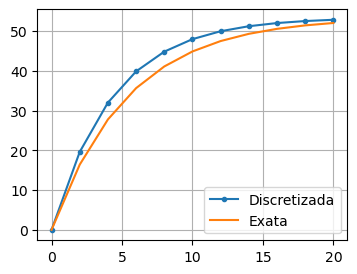

In [90]:
v_exa = lambda t: (m*g/c)*(1-np.exp(-c*t/m))

plt.plot(t,vi,".-", label="Discretizada")
plt.plot(t,  v_exa(t),"-", label="Exata")
plt.grid()
plt.legend()
plt.show()

**Atividade 3.3:** 

**1.** Como no Exemplo 3.3, aproxime a derivada por diferenças finitas,

$$
y^{\prime}\left(x_i\right) \approx \frac{y_{i+1}-y_i}{x_{i+1}-x_i}
$$

e utilize essa aproximação para obter uma solução numérica do problema

$$
y^{\prime}=\left(x^2+1\right) e^x, \quad y(0)=3,
$$

no intervalo $x\in[0,2]$, utilizando diferentes passos de discretização. Compare as soluções numéricas obtidas com a solução exata

$$
y(x)=e^x\left(x^2-2 x+3\right) .
$$

**2.** Como no Exemplo 3.3, aproxime a derivada por diferenças finitas,

$$y^{\prime}\left(t_i\right) \approx \frac{y_{i+1}-y_i}{t_{i+1}-t_i}$$

e utilize essa aproximação para obter uma solução numérica do problema

$$y^{\prime}=\left(t^2+1\right) \cos (t), \quad y(0)=0,$$

no intervalo $t\in[0,2]$, utilizando diferentes passos de discretização. Compare as soluções numéricas obtidas com a solução exata

$$y(t)=\left(t^2-1\right) \sin (t)+2 t \cos (t) .$$

### Casos bidimensionais 
Para os casos bidimensionais podemos combinar algumas dessas funções e obter coordenadas de pontos no plano. Vejamos alguns exemplos.


Coordenadas x: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3. ]
Coordenadas y: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ]


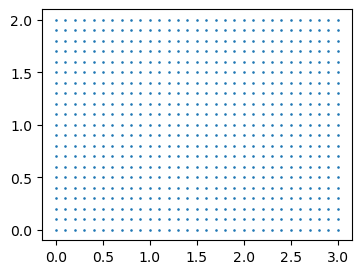

In [65]:
# Exemplo de discretização de uma região plana retangular
x = np.linspace(0,3,31)
y = np.linspace(0,2,21)

print ("Coordenadas x:", x)
print ("Coordenadas y:", y)

# usando a função meshgrid
xv, yv = np.meshgrid(x, y)
plt.scatter(xv, yv, marker='.', s=3)
plt.show()

Coordenadas r: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3. ]
Coordenadas t: [0.         0.05235988 0.10471976 0.15707963 0.20943951 0.26179939
 0.31415927 0.36651914 0.41887902 0.4712389  0.52359878 0.57595865
 0.62831853 0.68067841 0.73303829 0.78539816 0.83775804 0.89011792
 0.9424778  0.99483767 1.04719755 1.09955743 1.15191731 1.20427718
 1.25663706 1.30899694 1.36135682 1.41371669 1.46607657 1.51843645
 1.57079633]


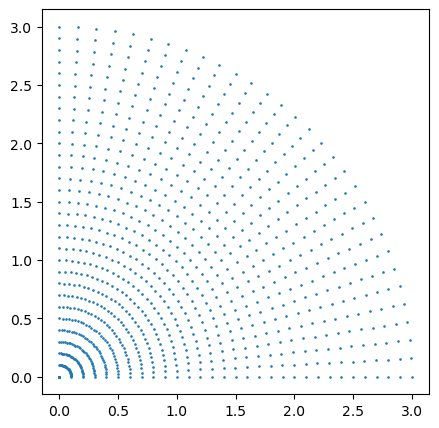

In [66]:
# Exemplo de discretização de um setor circular
r = np.linspace(0,3, 31)
t = np.linspace(0, np.pi/2, 31)

print ("Coordenadas r:", r)
print ("Coordenadas t:", t)

# usando a função meshgrid
rv, tv = np.meshgrid(r, t)

plt.figure(figsize=(5, 5))
plt.scatter(rv*np.cos(tv), rv*np.sin(tv), marker='.', s=3)
plt.show()

Coordenadas x: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3. ]
Coordenadas y: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ]


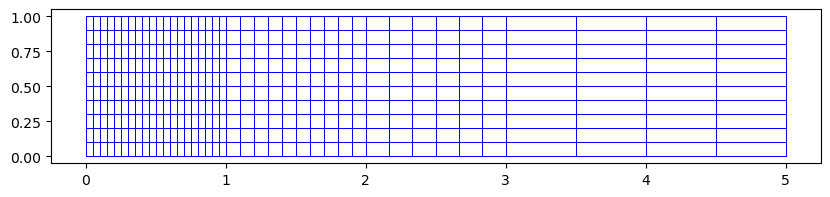

In [67]:
# Outro caso: concatenando arrays em x para criar com 4 resoluções
x1 = np.linspace(0, 1, 21)
x2 = np.linspace(1, 2, 11)
x3 = np.linspace(2, 3, 7)
x4 = np.linspace(3, 5, 5)
x_pts = np.concatenate((x1[:-1], x2[:-1],x3[:-1], x4))

y_pts = np.linspace(0, 1, 11)

print ("Coordenadas x:", x)
print ("Coordenadas y:", y)

fig, ax = plt.subplots(figsize=(10,2))

for y in y_pts:
    for x in x_pts:
        plt.hlines(y, x_pts[0],x_pts[-1],'b',lw=0.5)
        plt.vlines(x, y_pts[0],y_pts[-1],'b',lw=0.5)
        

plt.gca().set_aspect('equal')
plt.show() 

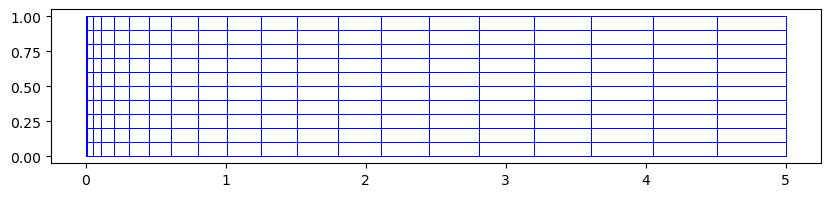

In [68]:
#Outro caso: espaçamento em x crescendo quadraticamente
x = np.linspace(0, 1, 21)

y_pts = np.linspace(0, 1, 11)
x_pts = 5*np.linspace(0, 1, 21)**2

fig, ax = plt.subplots(figsize=(10,2))

for y in y_pts:
    for x in x_pts:
        plt.hlines(y, x_pts[0],x_pts[-1],'b',lw=0.5)
        plt.vlines(x, y_pts[0],y_pts[-1],'b',lw=0.5)
        
ax.set_aspect('equal')
plt.show() 

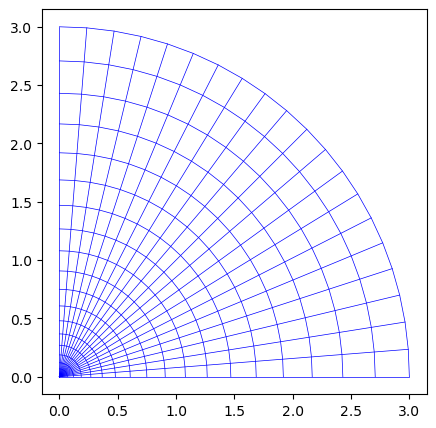

In [69]:
# Exemplo de discretização de um setor circular variando r quadraticamente
r = 3*np.linspace(0, 1, 21)**2
t = np.linspace(0, np.pi/2, 21)

fig, ax = plt.subplots(figsize=(5,5))

for ti in t:
    plt.plot(r*np.cos(ti), r*np.sin(ti), 'b', lw=0.5)
for ri in r:
    plt.plot(ri*np.cos(t), ri*np.sin(t), 'b', lw=0.5)

plt.gca().set_aspect('equal')
plt.show() 

**Referências**

BURDEN, Richard L. e FAIRES, J. Douglas. Análise Numérica. Tradução da 10ª edição norte-americana, 2016. Ed Cengage.

CHAPRA, Steven S. e CANALE, Raymond P. Métodos Numéricos para Engenharia. 7ª Edição. Editora McGraw-Hill.